# <center>Clustering Analysis<center>

<p>Team Name: Team Regular
<p>Student Names: Alameen Adeku, Adam Rodi, Adriean Lemoine, Nicholas Burgo

## Instructions
Use generic coding style unless hard-coded values are really necessary.<br>
Your code must be efficient and use self-explanatory naming.<br>
Use appropriate Python library methods for each task instead of using loops.<br>
Run your entire code and save. Then submit this <b>saved</b> copy.

## Imports

In [65]:
from itertools import combinations
import math
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
from pathlib import Path
from scipy import ndimage
import seaborn as sns
from skimage.filters.rank import entropy
from skimage.morphology import ball
from sklearn.preprocessing import MinMaxScaler
import tifffile as tfl

## Configurations

In [31]:
# --- Directory Configs ---

data_dir = os.path.join('..', 'Data')
input_data_dir = os.path.join(data_dir, 'input/zebrafish_tiff_scans')
output_dir = os.path.join(data_dir, 'output')
output_csv_dir = os.path.join(output_dir, 'csv')
output_figures_dir = os.path.join(output_data_dir, 'figures')

# Format of data files which prefix the sequential sample number
# Ex: 'ZS-1.tif' would have a data file prefix of 'ZS-'
data_file_prefix = 'ZS-' 

groups = {
    "control": "control",
    "anesthetic": "anesthetic",
    "stimulant": "stimulant"
}


## Functions

### Data generation

In [32]:
def load_tiff_stack(path):
    '''Load a single TIFF file into a 3D array'''
    sample = tfl.imread(path).astype(float)
    return sample

def compute_sample_gradient(tiff_stack):
    """Compute a 3D gradient magnitude map using Sobel filters along all axes."""
    gx = ndimage.sobel(tiff_stack, axis=0)
    gy = ndimage.sobel(tiff_stack, axis=1)
    gz = ndimage.sobel(tiff_stack, axis=2)
    sample_gradients = np.sqrt(gx**2 + gy**2 + gz**2)
    # print("Gradient sample (first 10 values):", np.round(sample_gradients.ravel()[:10], 3))
    return sample_gradients

def compute_sample_texture(tiff_stack, size=3):
    """Compute a 3D texture map as the local standard deviation of voxel intensities in a cubic neighborhood."""
    if isinstance(size, int):
        size = (size, size, size)
    
    # local mean of X
    mean = ndimage.uniform_filter(tiff_stack, size=size, mode='reflect')
    # local mean of X^2
    mean_sq = ndimage.uniform_filter(tiff_stack * tiff_stack, size=size, mode='reflect')
    
    # variance = E[X^2] - (E[X])^2
    var = mean_sq - mean * mean
    var = np.maximum(var, 0.0)  # avoid small negative due to rounding
    sample_textures = np.sqrt(var)
    # print("Texture sample (first 10 values):", np.round(sample_textures.ravel()[:10], 3))
    return sample_textures

def compute_sample_average(array_3d):
    """Compute the mean (average) of all values in a 3D array."""
    sample_average = float(np.mean(array_3d))  
    return sample_average

def compute_sample_std(array_3d):
    """Compute the standard deviation of all values in a 3D array."""
    sample_std = float(np.std(array_3d))
    return sample_std
    
def summarize_fish_sample(n, fish_class, intensity_array, gradient_array, texture_array):
    """Consolidate all summary data for a single fish sample into a dictionary of values."""
    return {
        "fish_id": n,
        "fish_class": fish_class,
        "avg_intensity": compute_sample_average(intensity_array),
        "avg_gradient": compute_sample_average(gradient_array),
        "avg_texture": compute_sample_average(texture_array),
        "std_intensity": compute_sample_std(intensity_array),
        "std_gradient": compute_sample_std(gradient_array),
        "std_texture": compute_sample_std(texture_array)
    }

def get_fish_sample(n, fish_class, path):
    """Takes in fish sample metadata, calculates intensity/gradient/texture data, and outputs a single dictionary summarizing the fish data."""
    intensity_array = load_tiff_stack(path)
    gradient_array = compute_sample_gradient(intensity_array)
    texture_array = compute_sample_texture(intensity_array)
    summary_dict = summarize_fish_sample(n, fish_class, intensity_array, gradient_array, texture_array)
    return summary_dict

def build_dataset(input_data_dir, groups, file_prefix="ZS-", num_files=10):
    """
    Process all zebrafish TIFF scans across groups and return a list of per-fish summary dictionaries.
    
    Args:
        input_data_dir : str
            Path to the folder containing group subfolders.
        groups : dict
            Dictionary mapping group names (str) to subfolder names.
            Example: {"control": "control", "anesthetic": "anesthetic", "stimulant": "stimulant"}
        file_prefix : str
            Prefix for fish filenames (default "ZS-")
        num_files : int
            Number of fish per group (default 10)
    
    Returns:
        samples : list of dict
            Each dict contains fish_id, fish_class, avg/std of intensity, gradient, and texture.
    """
    dataset = []
    fish_id = 1

    for fish_class, group_folder in groups.items():
        group_path = Path(input_data_dir) / group_folder

        for i in range(1, num_files + 1):
            filename = f"{file_prefix}{i}.tif"
            file_path = group_path / filename
            
            if not file_path.exists():
                print(f"Warning: File not found: {file_path}")
                continue

            # Compute single-fish sample dictionary
            sample = get_fish_sample(fish_id, fish_class, str(file_path))
            dataset.append(sample)
            fish_id += 1
    
    return dataset

def dataset_to_dataframe(dataset):
    """Convert a list of per-fish dictionaries into a pandas DataFrame."""
    df = pd.DataFrame(dataset)
    return df

def dataframe_to_csv(df, output_dir, filename="dataset.csv"):
    """Save a pandas DataFrame to a CSV file in the specified directory."""
    os.makedirs(output_dir, exist_ok=True)  # make sure directory exists
    csv_path = os.path.join(output_dir, filename)
    df.to_csv(csv_path, index=False)        # index=False to omit row numbers
    print(f"DataFrame saved to: {csv_path}")
    return csv_path

def normalize_dataframe(df, feature_columns):
    """
    Normalize specified columns of a DataFrame to the 0-1 range using Min-Max scaling.
    
    Args:
        df : pd.DataFrame
            The input DataFrame.
        feature_columns : list of str
            List of column names to normalize 
            Example: numeric feature columns
    
    Returns:
        df_normalized : pd.DataFrame
            A copy of the DataFrame with the specified columns normalized to [0, 1].
    """
    df_normalized = df.copy()
    scaler = MinMaxScaler()
    
    # Fit and transform only the selected feature columns
    df_normalized[feature_columns] = scaler.fit_transform(df_normalized[feature_columns])
    
    return df_normalized



### Plotting

In [62]:
def plot_histograms(df, feature_columns, figure_dir, filename='histograms.png', bins=30, class_column=None, palette='Set2'):
    """Plot histograms for numeric features, optionally colored by class/group."""
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    axes = axes.flatten()
    
    for col, ax in zip(feature_columns, axes):
        if class_column:
            sns.histplot(data=df, x=col, hue=class_column, bins=bins, palette=palette, multiple='dodge', ax=ax)
        else:
            sns.histplot(df[col], bins=bins, ax=ax, color='#4c72b0')
        ax.set_title(f'{col.title()} histogram')
    
    plt.tight_layout()
    out_path = os.path.join(figure_dir, filename)
    fig.savefig(out_path, dpi=300, bbox_inches='tight')
    print(f"Saved: {out_path}")
    plt.show()
    plt.close(fig)


def plot_kde_distributions(df, feature_columns, figure_dir, filename='densities.png', class_column=None, palette='Set2'):
    """Plot KDE density plots for numeric features, optionally colored by class/group."""
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    axes = axes.flatten()
    
    for col, ax in zip(feature_columns, axes):
        if class_column:
            sns.kdeplot(data=df, x=col, hue=class_column, fill=True, palette=palette, ax=ax)
        else:
            sns.kdeplot(df[col], fill=True, ax=ax, color='#55a868')
        ax.set_title(f'{col.title()} density')
    
    plt.tight_layout()
    out_path = os.path.join(figure_dir, filename)
    fig.savefig(out_path, dpi=300, bbox_inches='tight')
    print(f"Saved: {out_path}")
    plt.show()
    plt.close(fig)


def plot_boxplots(df, feature_columns, figure_dir, filename='boxplots.png', class_column=None, palette='Set2'):
    """Create horizontal boxplots for multiple features, optionally grouped by class."""
    if class_column:
        melted = df.melt(id_vars=class_column, value_vars=feature_columns,
                         var_name='feature', value_name='value')
        sns_box_kwargs = dict(data=melted, x='value', y='feature', hue=class_column, orient='h', palette=palette)
    else:
        melted = df[feature_columns].melt(var_name='feature', value_name='value')
        sns_box_kwargs = dict(data=melted, x='value', y='feature', orient='h', color='#8172b2')
    
    plt.figure(figsize=(10, 6))
    sns.boxplot(**sns_box_kwargs)
    plt.title('Box plots per feature')
    plt.tight_layout()
    
    fig = plt.gcf()
    out_path = os.path.join(figure_dir, filename)
    fig.savefig(out_path, dpi=300, bbox_inches='tight')
    print(f"Saved: {out_path}")
    plt.show()
    plt.close(fig)


def plot_violinplots(df, feature_columns, figure_dir, filename='violins.png', class_column=None, palette='Set2'):
    """Create horizontal violin plots with quartiles, optionally colored by class/group."""
    if class_column:
        melted = df.melt(id_vars=class_column, value_vars=feature_columns,
                         var_name='feature', value_name='value')
        sns_violin_kwargs = dict(data=melted, x='value', y='feature', hue=class_column,
                                 orient='h', inner='quartile', palette=palette, legend=True)
    else:
        melted = df[feature_columns].melt(var_name='feature', value_name='value')
        sns_violin_kwargs = dict(data=melted, x='value', y='feature', orient='h', inner='quartile', palette=palette)
    
    plt.figure(figsize=(10, 6))
    sns.violinplot(**sns_violin_kwargs)
    plt.title('Violin plots with quartiles')
    plt.tight_layout()
    
    fig = plt.gcf()
    out_path = os.path.join(figure_dir, filename)
    fig.savefig(out_path, dpi=300, bbox_inches='tight')
    print(f"Saved: {out_path}")
    plt.show()
    plt.close(fig)

def plot_scatter_pairs(df, numeric_columns, class_column, figure_dir, filename='scatter_plots.png', alpha=0.8, s=50, palette='dark', n_cols=3):
    """
    Create scatter plots for all pairwise combinations of numeric features, colored by a class/group column.
    Arranges plots in a grid with a specified number of columns per row.

    Args:
        df : DataFrame
        numeric_columns : list of str, numeric features to plot
        class_column : str, column to color by
        figure_dir : str, directory to save figure
        filename : str, name of saved figure
        alpha : float, transparency of points
        s : int, marker size
        palette : str or dict, seaborn color palette
        n_cols : int, number of plots per row
    """
    scatter_pairs = list(combinations(numeric_columns, 2))
    n_plots = len(scatter_pairs)
    n_rows = math.ceil(n_plots / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 5*n_rows))
    
    # Flatten axes array for easy indexing
    axes = axes.flatten() if n_plots > 1 else [axes]

    for idx, ((x_col, y_col), ax) in enumerate(zip(scatter_pairs, axes)):
        sns.scatterplot(
            data=df,
            x=x_col,
            y=y_col,
            hue=class_column,
            alpha=alpha,
            s=s,
            palette=palette,
            ax=ax
        )
        ax.set_title(f'{x_col.title()} vs {y_col.title()}')
        ax.legend().set_title(class_column.title())

    # Turn off any unused subplots
    for ax in axes[n_plots:]:
        ax.axis('off')
    
    plt.tight_layout()
    out_path = os.path.join(figure_dir, filename)
    fig.savefig(out_path, dpi=300, bbox_inches='tight')
    print(f"Saved: {out_path}")
    plt.show()
    plt.close(fig)

## Read Data

### Load Fish Scans

In [27]:
# Build the dataset
dataset = build_dataset(input_data_dir, groups, file_prefix="ZS-", num_files=10)

# Convert to DataFrame
df = dataset_to_dataframe(dataset)

# Output dataframe to csv
csv_path = dataframe_to_csv(df, output_csv_dir)


DataFrame saved to: ../Data/output/csv/dataset.csv


In [36]:
# Inspect
# print(df)


In [ ]:
# Gather feature columns and normalize dataframe
feature_cols = ['avg_intensity', 'avg_gradient', 'avg_texture', 'std_intensity', 'std_gradient', 'std_texture']
df_norm = normalize_dataframe(df, feature_cols)

In [37]:
# print(df_norm)

## Visual Exploration of Data

### Histograms

Saved: ../Data/output/figures/histograms.png


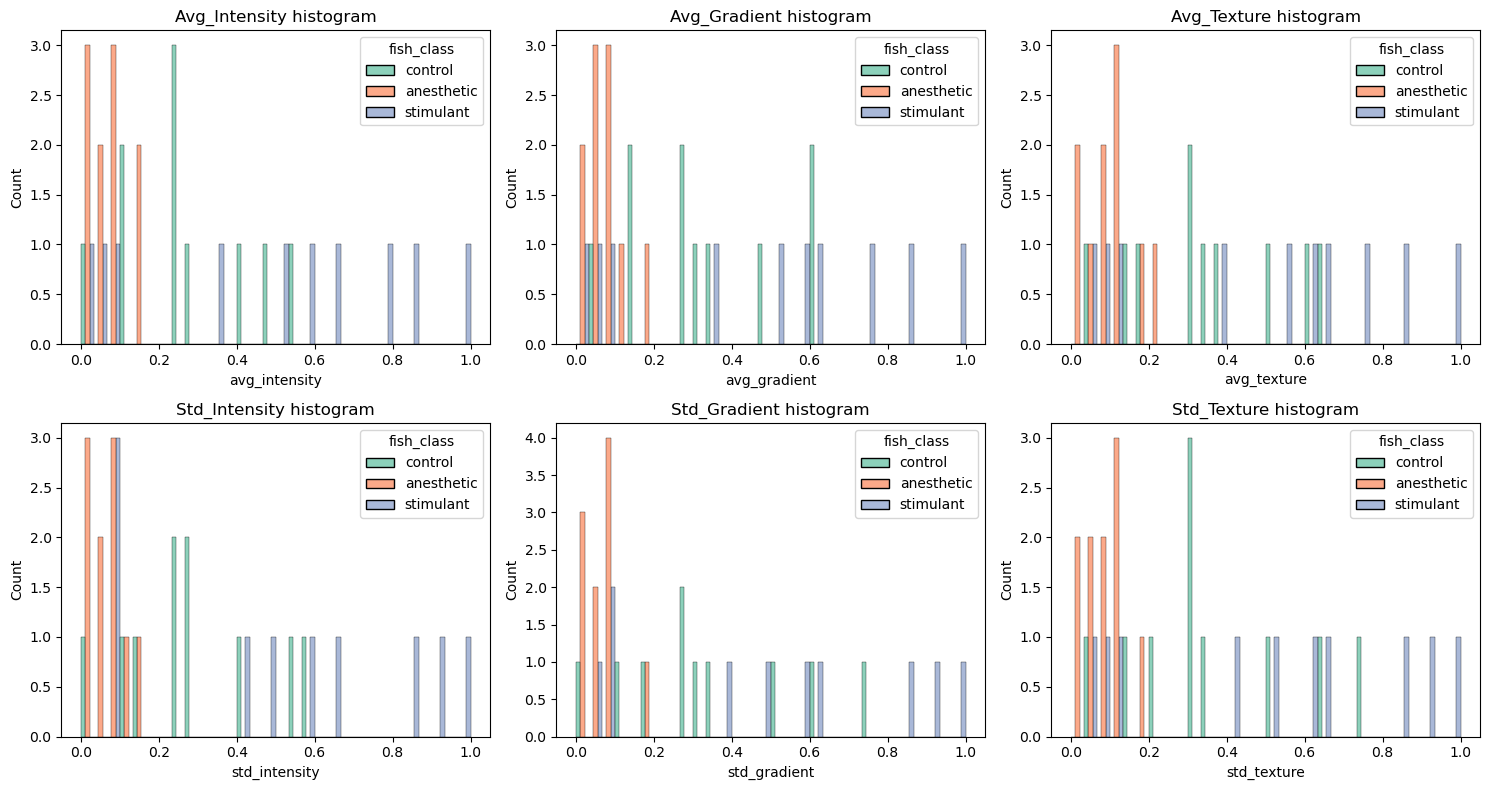

In [46]:
plot_histograms(df_norm, feature_cols, output_figures_dir, class_column="fish_class")

### Distributions

Saved: ../Data/output/figures/densities.png


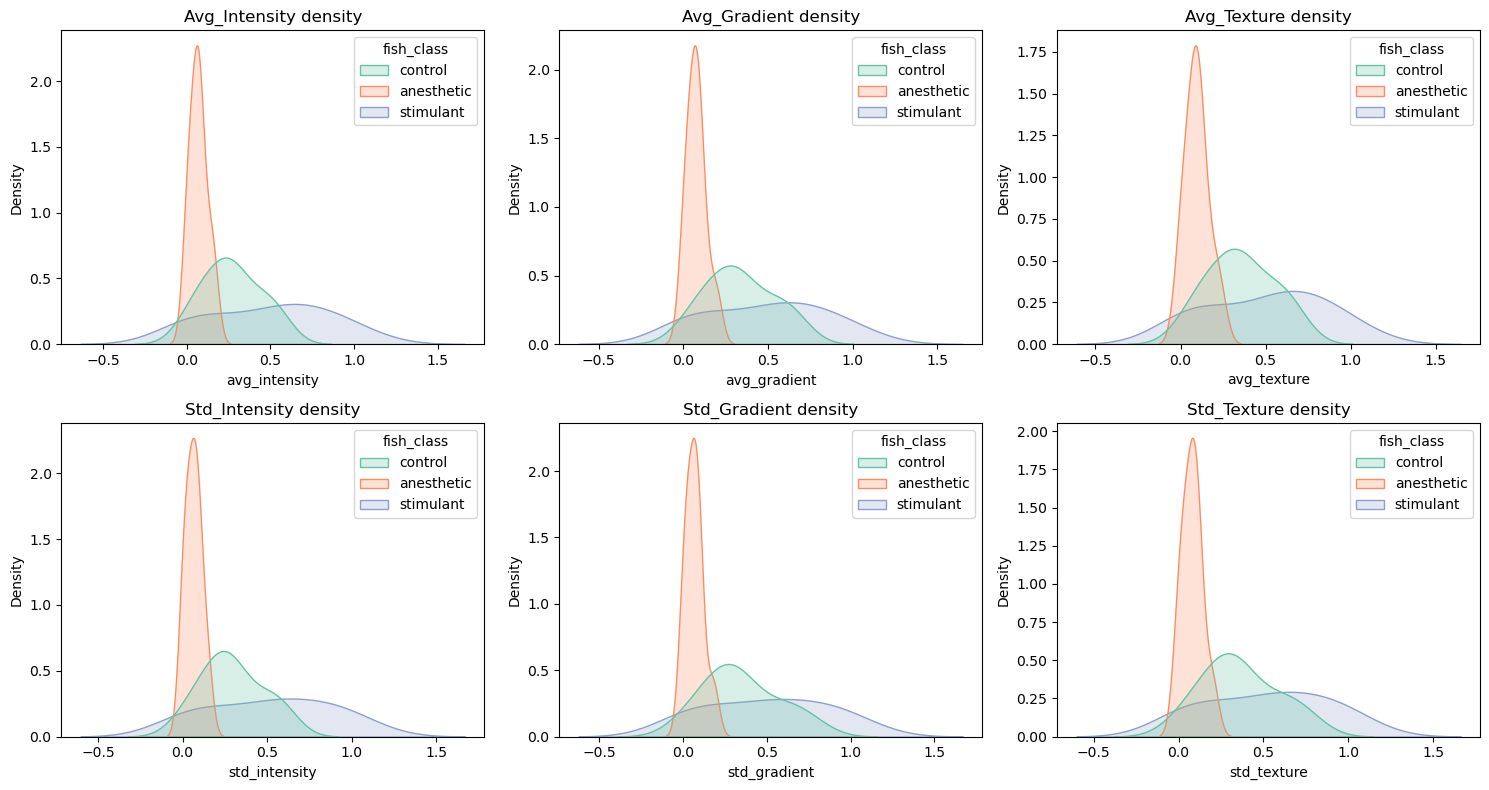

In [45]:
plot_kde_distributions(df_norm, feature_cols, output_figures_dir, class_column="fish_class")

### Box-Whisker Plots

Saved: ../Data/output/figures/boxplots.png


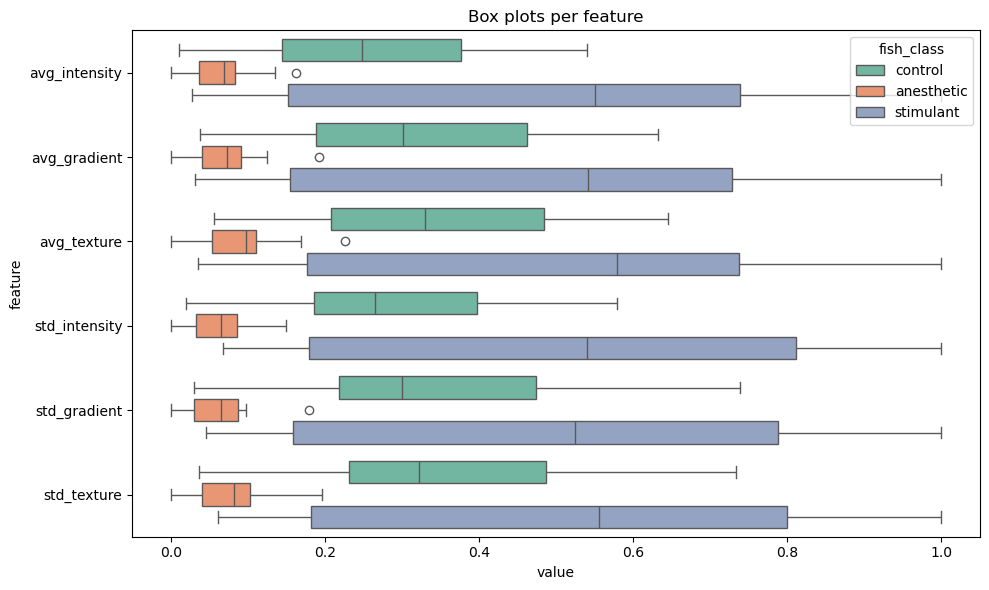

In [51]:
plot_boxplots(df_norm, feature_cols, output_figures_dir, class_column="fish_class")

### Violin Plots

Saved: ../Data/output/figures/violins.png


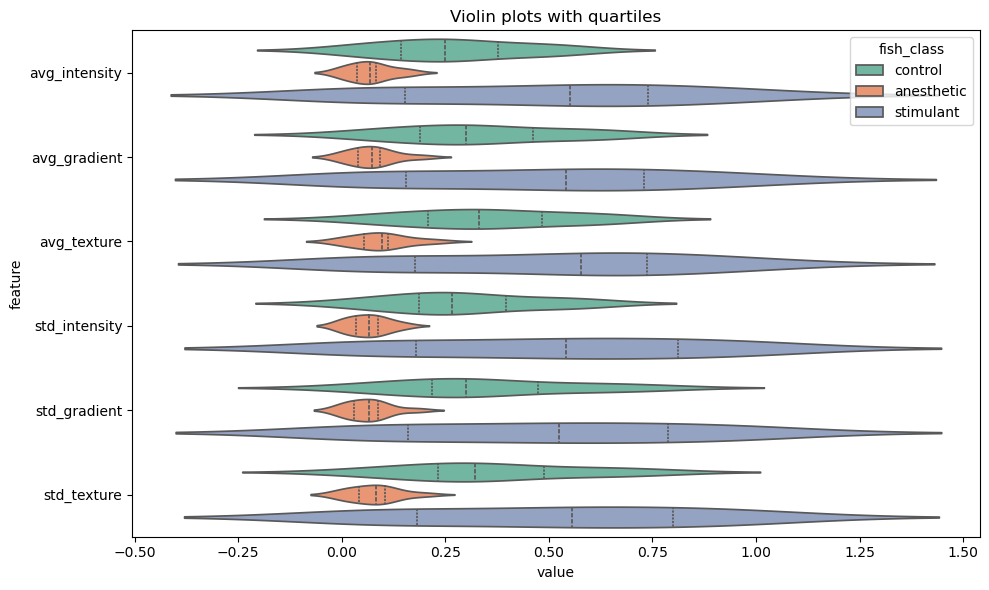

In [56]:
plot_violinplots(df_norm, feature_cols, output_figures_dir, class_column="fish_class")

### Scatter Plots

Saved: ../Data/output/figures/scatter_plots.png


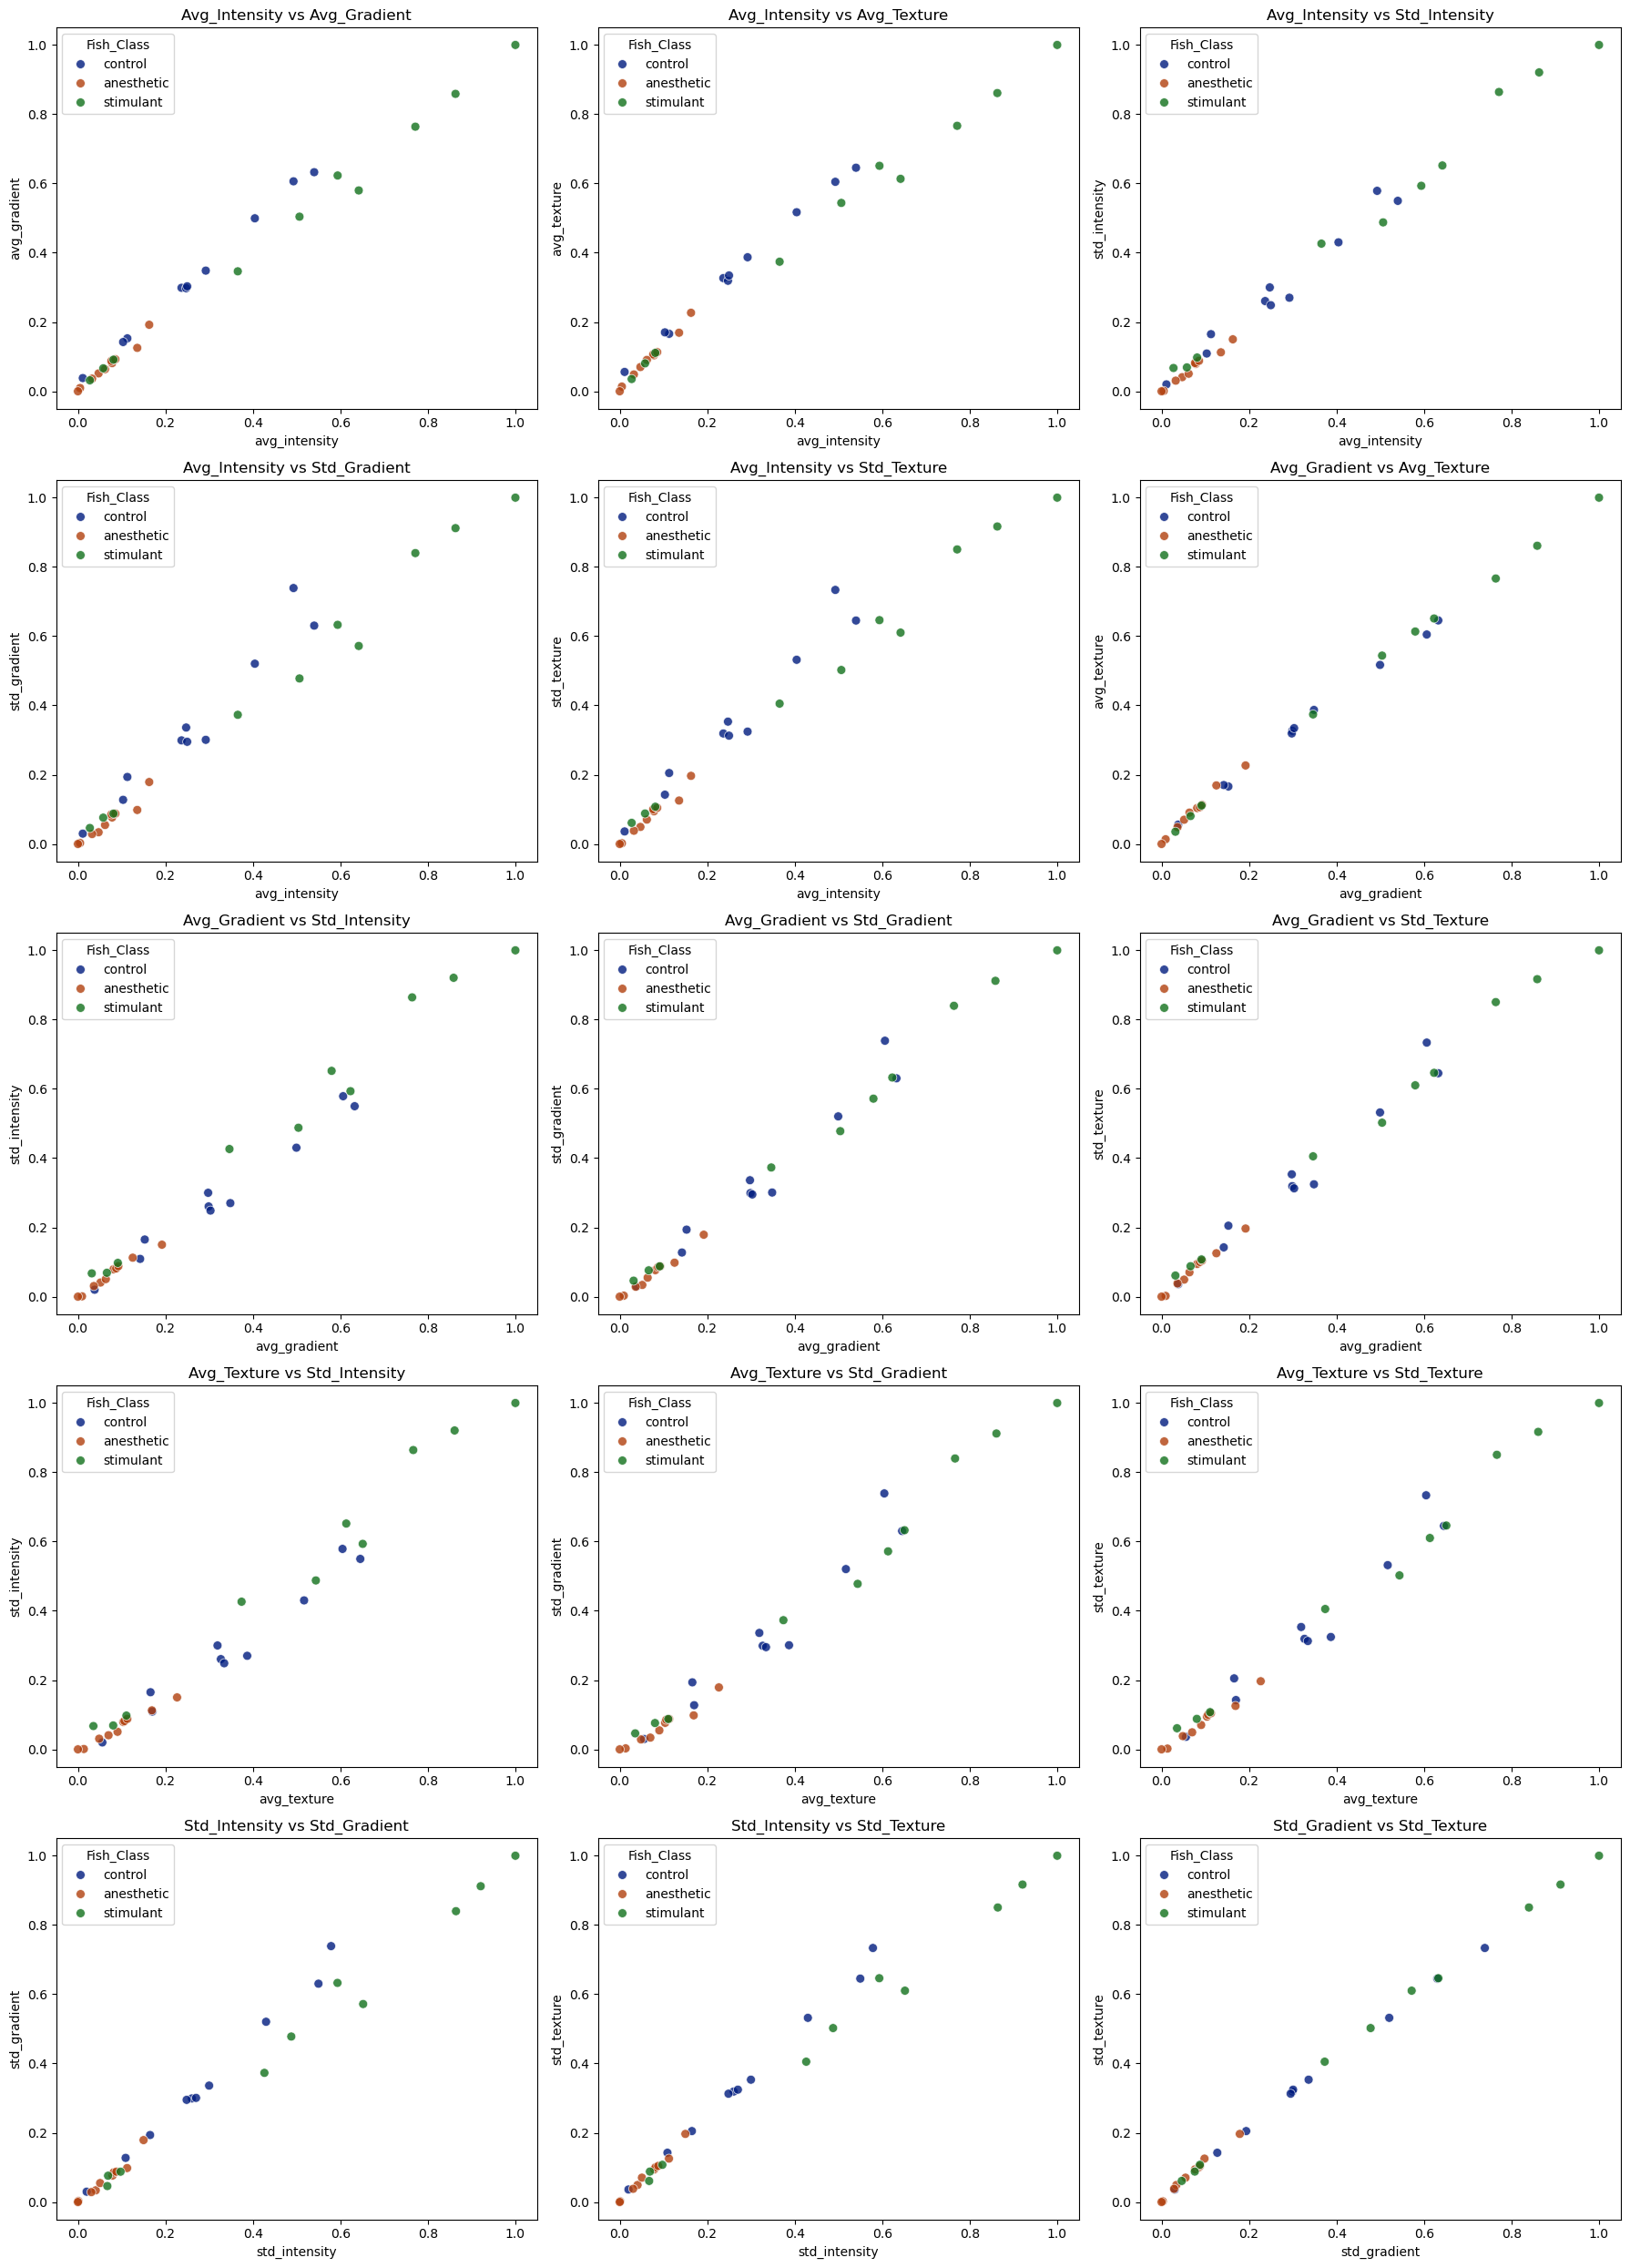

In [66]:
plot_scatter_pairs(df_norm, feature_cols, class_column='fish_class', figure_dir=output_figures_dir, s=50, alpha=0.8, palette='dark', n_cols=3)


## Data Quality & Cleaning

Instruction: Add a comment for each method

## Handling Redundancy

### X-square Test

### Correlation Analysis

### Visual Exploration (scatter-plot matrix)

## Dimensionality Reduction

### PCA

## Discretization

### Histogram of Discretized Attribute

### X-square Test of Discretized Attributes

### Visual Exploration (scatter-plot matrix) of Discretized Attributes

## Feature Selection/Generation

### Select Features

### Generate Features

# Generate Clusters

## K-means

## Hierarchical

# Evaluation of Clusters

See instructions provided in the report template

## <center> REFERENCES </center>
List resources (book, internet page, etc.) that you used to complete this challenge.

- https://numpy.org/doc/2.3/index.html
- https://pandas.pydata.org/docs/
- http://pypi.org/project/tifffile/